### 1. generate mock spectra

Reading DESI_templates/bgs_templates_v2.3.fits metadata.
DESI_templates/bgs_templates_v2.3.fits
Reading DESI_templates/bgs_templates_v2.3.fits


wave (32001,) 3600.0 10000.0
flux (32001,) 0.5642047699434134 3.5470792768626795
TARGETID OBJTYPE SUBTYPE TEMPLATEID SEED REDSHIFT    MAG     MAGFILTER     FLUX_G      FLUX_R      FLUX_Z     FLUX_W1     FLUX_W2  
                                                     mag                nanomaggies nanomaggies nanomaggies nanomaggies nanomaggies
-------- ------- ------- ---------- ---- -------- --------- ----------- ----------- ----------- ----------- ----------- -----------
       0     BGS               1740    1      0.1 20.171188 decam2014-r    4.534349   8.5413065   13.707776   13.687502   9.9576645
TARGETID    OIIFLUX      HBETAFLUX    EWOII    EWHBETA    D4000     VDISP   OIIDOUBLET OIIIHBETA    OIIHBETA    NIIHBETA    SIIHBETA   TRANSIENT_MODEL TRANSIENT_TYPE TRANSIENT_EPOCH TRANSIENT_RFLUXRATIO
         erg / (s cm2) erg / (s cm2) Angstrom  Angstrom             km / s                Dex         Dex         Dex         Dex                                            d              

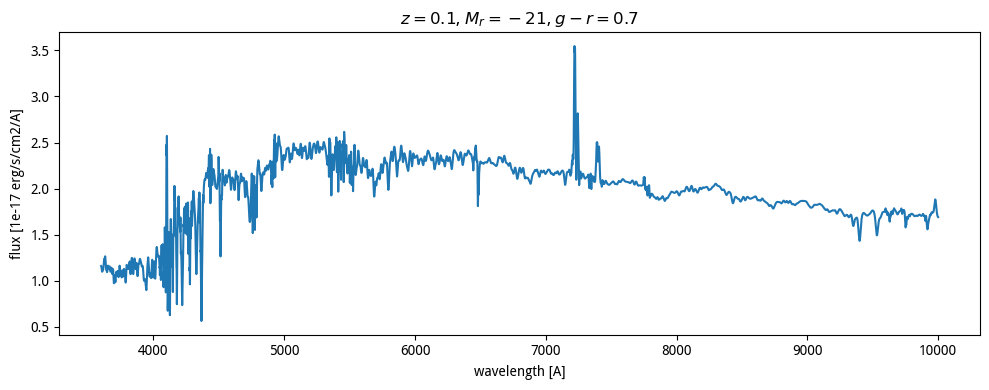

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
from just_specsim.maker import SpectrumMaker

maker = SpectrumMaker()
wave, flux, meta, objmeta = maker(z=0.1, Mr=-21.0, color=0.7, saveto='./mockspectra/')

print('wave', np.shape(wave), wave.min(), wave.max())
print('flux', np.shape(flux), flux.min(), flux.max())
print(meta)
print(objmeta)
print('saved', sorted(os.listdir('./mockspectra/')))

plt.figure(figsize=(10, 4))
plt.plot(wave, flux)
plt.xlabel('wavelength [A]')
plt.ylabel('flux [1e-17 erg/s/cm2/A]')
plt.title(r'$z=0.1$, $M_r=-21$, $g-r=0.7$')
plt.tight_layout()
plt.show() 

### 2. convert to observed spectra
#### Here！ You need to using just_etc to generate the observed spectra. 

      JUST ETC Parallel Simulator (10,000 Spectra -> Redrock FITS)
 📂 Input FITS File : mockspectra/spectra.fits
 📂 Output FITS File: observed-spectra.fits
 ⚙️ Parallel Cores  : 1 Workers
 ⏱️ Observation     : 4 x 900s (Total 1.00 hrs)
 ✅ Loaded 1 spectra with 32001 wavelength points (3600.0 - 10000.0 Å)

🚀 Launching 1 parallel worker tasks across 1 CPU cores...


ETC Calculation Mode: FAST {'geo_nu': 20, 'geo_du': 0.06, 'atm_step': 0.5, 'cont_samp': 2, 'snr_stride': 10}
 //Arm0//
  --> Computing Sky Lines Contribution ...
  --> Computing Sky Continuum Contribution ...
 //Arm1//
  --> Computing Sky Lines Contribution ...
  --> Computing Sky Continuum Contribution ...
 //Arm2//
  --> Computing Sky Lines Contribution ...
  --> Computing Sky Continuum Contribution ...
 Progress: [1/1] chunks completed (100.0%)
✅ All parallel worker tasks finished! Assembling Redrock FITS extensions...
---------------------------------------------------------------------------
🎉 Successfully generated Redrock FITS file!
 📂 Output Path  : observed-spectra.fits
 📊 File Size    : 0.29 MB
 ⏱️ Total Time   : 60.15 seconds (0.0 spectra/sec)
---------------------------------------------------------------------------
wrote /home/yzgu/work/work-just/just_mospec/tutorial/specsimu/observed-spectra.fits
 TARGETID INTEG_RAW_FLUX_B MEDIAN_RAW_FLUX_B ... MEDIAN_RAW_FLUX_Z SNR_Z 
-

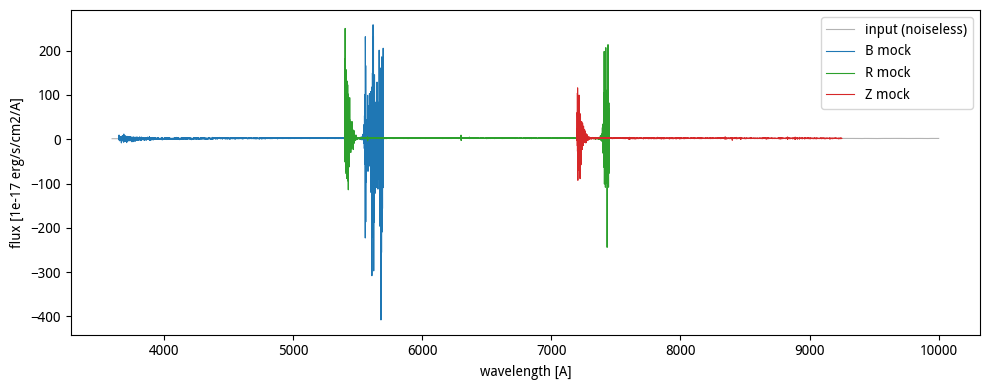

In [10]:
# Convert mockspectra/spectra.fits -> observed-spectra.fits with just_etc.
# Install: pip install git+https://github.com/RainW7/just_etc.git
# process_bgs_10k_redrock.py is the archived parallel converter from
# https://github.com/RainW7/just_etc/blob/main/examples/archive/process_bgs_10k_redrock.py
# Input must be HDU0=WAVELENGTH, HDU1=FLUX in 10^-17 erg/s/cm2/A.


import os
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from astropy.table import Table

from process_bgs_10k_redrock import process_spectral_library

input_fits  = './mockspectra/spectra.fits'
output_fits = './observed-spectra.fits'

out = process_spectral_library(
    input_fits_path=input_fits,
    output_fits_path=output_fits,
    t_exp=900.0,
    n_exp=4,
    seeing_fwhm=0.8,
    nproc=1,
)
print('wrote', Path(out).resolve())

with fits.open(input_fits) as hdul:
    wave_in = np.asarray(hdul[0].data)
    flux_in = np.atleast_2d(np.asarray(hdul[1].data))[0]

scores = Table.read(output_fits, hdu='SCORES')
print(scores)

plt.figure(figsize=(10, 4))
plt.plot(wave_in, flux_in, color='0.7', lw=0.8, label='input (noiseless)')
with fits.open(output_fits) as hdul:
    for band, color in zip(('B', 'R', 'Z'), ('C0', 'C2', 'C3')):
        wave = hdul[f'{band}_WAVELENGTH'].data
        flux = np.atleast_2d(hdul[f'{band}_FLUX'].data)[0]
        plt.plot(wave, flux, color=color, lw=0.8, label=f'{band} mock')
plt.xlabel('wavelength [A]')
plt.ylabel('flux [1e-17 erg/s/cm2/A]')
plt.legend()
plt.tight_layout()
plt.show()


In [27]:
from astropy.io import fits
from astropy.table import Table
import numpy as np 

output_fits = './observed-spectra.fits'

hdul = fits.open(output_fits)
fmap = Table(hdul['FIBERMAP'].data) 
fmap['TILEID'] = np.zeros(len(fmap), dtype=np.int32)
fmap['COADD_FIBERSTATUS'] = np.zeros(len(fmap), dtype=np.int32) 
hdul['FIBERMAP'] = fits.BinTableHDU(fmap, name='FIBERMAP')
hdul.writeto(output_fits, overwrite=True)
hdul.close()

fits.info('observed-spectra.fits')
print(Table(fits.getdata('observed-spectra.fits', 'FIBERMAP')).colnames)

Filename: observed-spectra.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  FIBERMAP      1 BinTableHDU     25   1R x 8C   [K, D, D, J, J, 3A, J, J]   
  2  B_WAVELENGTH    1 ImageHDU         7   (4096,)   float64   
  3  B_FLUX        1 ImageHDU         9   (4096, 1)   float32   
  4  B_IVAR        1 ImageHDU         9   (4096, 1)   float32   
  5  B_RESOLUTION    1 ImageHDU         9   (4096, 1, 1)   float32   
  6  R_WAVELENGTH    1 ImageHDU         7   (4096,)   float64   
  7  R_FLUX        1 ImageHDU         9   (4096, 1)   float32   
  8  R_IVAR        1 ImageHDU         9   (4096, 1)   float32   
  9  R_RESOLUTION    1 ImageHDU         9   (4096, 1, 1)   float32   
 10  Z_WAVELENGTH    1 ImageHDU         7   (4096,)   float64   
 11  Z_FLUX        1 ImageHDU         9   (4096, 1)   float32   
 12  Z_IVAR        1 ImageHDU         9   (4096, 1)   float32   
 13  Z_RESOLUTION    1 ImageHDU         9   (4096

### 3. get spectroscopic redshift 
#### run redrock to get spectroscopic redshift 

In [22]:
%%bash
# observed-spectra.fits  (-i)
#   DESI-like spectra.
#   HDUs: FIBERMAP (TARGETID, coordinates, FIBERSTATUS, ...), SCORES,
#   and per-band B/R/Z WAVE / FLUX / IVAR / MASK / RESOLUTION.

# rrdetails-input10k.h5  (--details)
#   Output: per-target chi2-vs-z scan, template coefficients, secondary
#   minima, etc. Large file; 
#   for diagnostics.

# redrock-input10k.fits  (--outfile)
#   Output: redshift catalog. Main table REDSHIFTS: Z, ZERR, ZWARN,
#   SPECTYPE, DELTACHI2, plus a copy of FIBERMAP.
#   This is usually the only file you need (e.g. success-rate stats).

rrdesi -i observed-spectra.fits \
    --details rrdetails.h5 \
    --outfile redrock.fits \
    --mp 1

Running with 1 multiprocesing processes
Loading targets...
no archetypes or --archetypes-no-legendre; will turn off all the Legendre related arguments
Read and distribution of 1 targets: 0.2 seconds
DEBUG: Reading templates from /home/yzgu/.conda/envs/py312/lib/python3.12/site-packages/redrock/data/templates
Reading templates from ['/home/yzgu/.conda/envs/py312/lib/python3.12/site-packages/redrock/data/templates/rrtemplate-GALAXY-None-v2.6.fits', '/home/yzgu/.conda/envs/py312/lib/python3.12/site-packages/redrock/data/templates/rrtemplate-QSO-LOZ-v1.0.fits', '/home/yzgu/.conda/envs/py312/lib/python3.12/site-packages/redrock/data/templates/rrtemplate-QSO-HIZ-v1.1.fits', '/home/yzgu/.conda/envs/py312/lib/python3.12/site-packages/redrock/data/templates/rrtemplate-STAR-A-v0.1.fits', '/home/yzgu/.conda/envs/py312/lib/python3.12/site-packages/redrock/data/templates/rrtemplate-STAR-B-v0.1.fits', '/home/yzgu/.conda/envs/py312/lib/python3.12/site-packages/redrock/data/templates/rrtemplate-STAR-C

### 4. success rate statistics 

N_TGT = 1 N_success = 1 rate = 1.0
 TARGETID OBJTYPE REDSHIFT ... SPECTYPE SUCCESS           DZ          
--------- ------- -------- ... -------- ------- ----------------------
300000001     TGT      0.1 ...   GALAXY    True 2.1005098622642326e-05


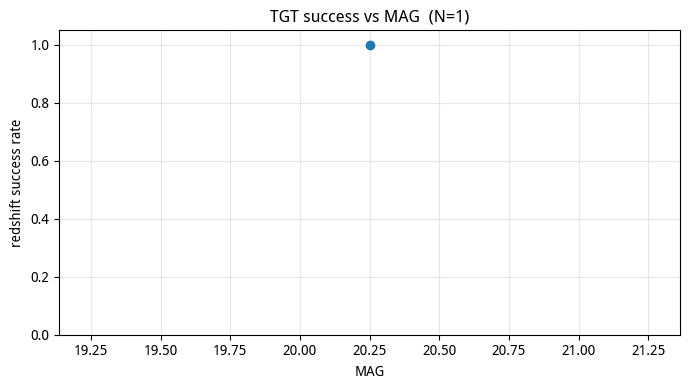

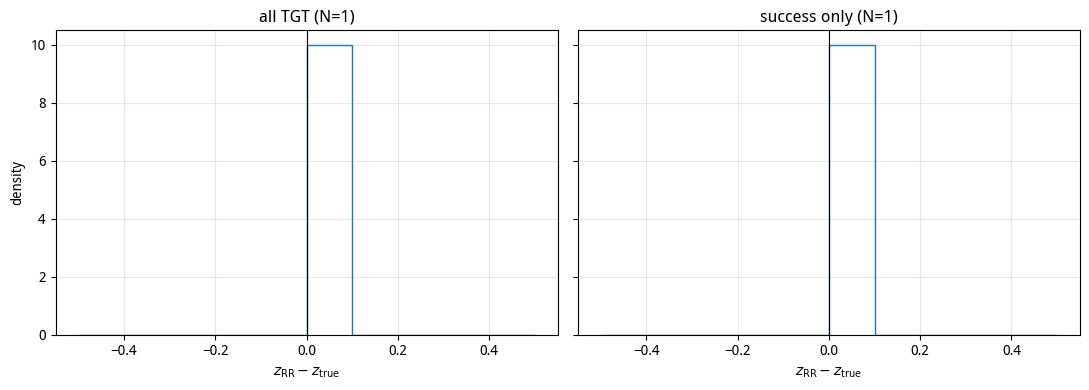

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, join

rr = 'redrock.fits'
meta_file = os.path.join('mockspectra', 'meta.fits')
targetid0 = 300000001

zcat = Table.read(rr, hdu='REDSHIFTS')
fmap = Table.read(rr, hdu='FIBERMAP')
meta = Table.read(meta_file)

obj = np.char.decode(np.asarray(fmap['OBJTYPE']).astype('S'), 'ascii')
tgt = fmap[obj == 'TGT'][['TARGETID', 'OBJTYPE']].copy()

rows = np.asarray(tgt['TARGETID'], dtype=np.int64) - targetid0
tgt['REDSHIFT'] = np.asarray(meta['REDSHIFT'][rows], dtype=float)
tgt['MAG'] = np.asarray(meta['MAG'][rows], dtype=float)

t = join(
    tgt,
    zcat[['TARGETID', 'Z', 'ZWARN', 'DELTACHI2', 'SPECTYPE']],
    keys='TARGETID',
    join_type='left',
)

success = (t['ZWARN'] == 0) & (t['DELTACHI2'] > 40)
t['SUCCESS'] = success
t['DZ'] = np.asarray(t['Z'], dtype=float) - np.asarray(t['REDSHIFT'], dtype=float)

n_tgt = len(t)
n_success = int(np.count_nonzero(success))
print('N_TGT =', n_tgt, 'N_success =', n_success,
      'rate =', n_success / n_tgt if n_tgt else np.nan)
print(t)

# success vs MAG
mag = np.asarray(t['MAG'], dtype=float)
bins = np.arange(np.floor(np.nanmin(mag)), np.ceil(np.nanmax(mag)) + 0.5, 0.5)
centers, rates = [], []
for lo, hi in zip(bins[:-1], bins[1:]):
    m = (mag >= lo) & (mag < hi)
    if np.any(m):
        centers.append(0.5 * (lo + hi))
        rates.append(success[m].mean())

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(centers, rates, 'o-')
ax.set_xlabel('MAG')
ax.set_ylabel('redshift success rate')
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
ax.set_title(f'TGT success vs MAG  (N={n_tgt})')
plt.tight_layout()
plt.show()

# dz histogram
dz_all = np.asarray(t['DZ'], dtype=float)
dz_ok  = np.asarray(t['DZ'][t['SUCCESS']], dtype=float)
clip = 0.01
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, arr, title in [
    (axes[0], dz_all, f'all TGT (N={n_tgt})'),
    (axes[1], dz_ok, f'success only (N={n_success})'),
]:
    a = arr[np.isfinite(arr)]
    a = a[(a > -clip) & (a < clip)]
    if len(a):
        ax.hist(a, bins=min(80, max(10, len(a))), histtype='step', density=True)
    ax.axvline(0, color='k', lw=0.8)
    ax.set_xlabel(r'$z_\mathrm{RR} - z_\mathrm{true}$')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('density')
plt.tight_layout()
plt.show()